In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import norm
import random
import math

In [42]:
#il nostro integrale ha una sorta di gaussiana. Sapendo quanti fa l'integrale gaussiano posso rinormalizzarla (vedi appunti)

sigma = 1 #decido il valore da dare a sigma nel risultato dell'integrale
xi=np.abs(np.random.normal(0, sigma, 100000)) #p(x): genera sample gaussiano e voglio solo valori positivi (per integrare tra 0 e infinito)

integral = ((np.sqrt(2*np.pi*sigma**2))/2) * np.mean((xi**3)) #integro la mia f(x) motliplicata per la normalizzazione

integral

2.001815746626052

In [43]:
#studio dei resdui all'aumentare del numero di sample (convergenza al valore vero) e andamento errori
true_v = 2*(sigma**4)
#N = np.linspace(100, 1000000, 10000, dtype=int) #genero sample di N tra 100 e 100000 con step 1000
N = np.unique(np.logspace(0,6,100,dtype=int))
print(N)
result_n = []
truev_vec = []

for i in range(len(N)):
    xi_n = np.abs(np.random.normal(0,sigma,N[i]))
    result_n.append(((np.sqrt(2*np.pi*sigma**2))/2) * np.mean(xi_n**3))
    #error_n.append(true_v-((np.sqrt(2*np.pi*sigma**2))/2) * np.mean((xi_n**3)))
    truev_vec.append(true_v)
    
error_n = (np.array(result_n) - true_v)/true_v

[      1       2       3       4       5       6       7       8       9
      10      12      14      16      18      21      24      28      32
      37      43      49      57      65      75      86     100     114
     132     151     174     200     231     265     305     351     403
     464     533     613     705     811     932    1072    1232    1417
    1629    1873    2154    2477    2848    3274    3764    4328    4977
    5722    6579    7564    8697   10000   11497   13219   15199   17475
   20092   23101   26560   30538   35111   40370   46415   53366   61359
   70548   81113   93260  107226  123284  141747  162975  187381  215443
  247707  284803  327454  376493  432876  497702  572236  657933  756463
  869749 1000000]


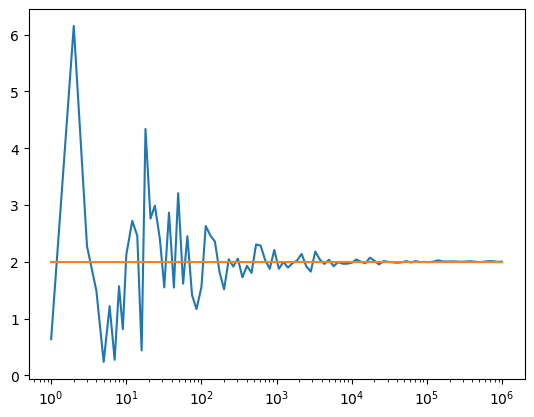

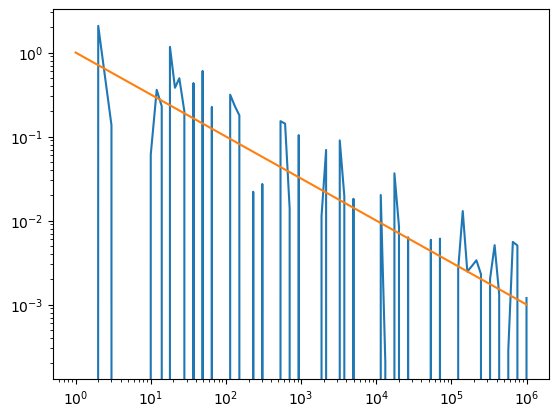

In [44]:
plt.plot(N,result_n)
plt.plot(N,truev_vec)
plt.xscale('log')
plt.show()

plt.plot(N, error_n)
plt.plot(N,N**(-0.5))
plt.loglog()
plt.show()

In [49]:
#andamento dei risultati per N fissato
result_fixedN = []
N = 10000

for i in range(N):
    xi_fixedN = np.abs(np.random.normal(0,sigma,N))
    result_fixedN.append(((np.sqrt(2*np.pi*sigma**2))/2) * np.mean(xi_fixedN**3))

In [50]:
def gauss_fit(x,mu,std): #definisco gaussiana analitica per fit
    return (1/np.sqrt(2 * np.pi * std**2)) * np.exp(- ((x-mu)**2) / (2 * std**2))

myfit = gauss_fit(np.linspace(np.min(result_fixedN),np.max(result_fixedN),N),np.mean(result_fixedN),np.std(result_fixedN))

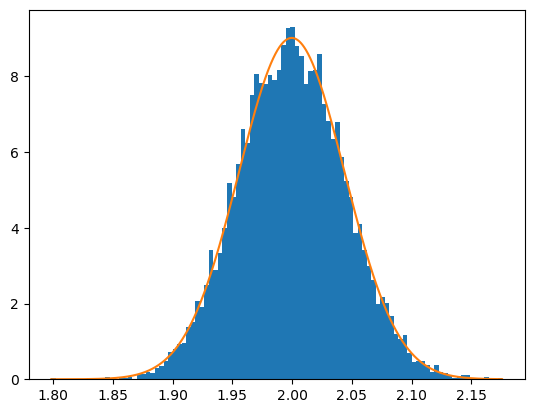

In [51]:
plt.hist(np.array(result_fixedN), bins=int(np.sqrt(N)), density=True)
plt.plot(np.linspace(np.min(result_fixedN),np.max(result_fixedN),N), myfit)